In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {'C': [1, 10, 100], 'gamma': [0.001, 0.01, 0.1]}

svm = SVC(kernel='rbf')

grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

best_svm = grid.best_estimator_
best_svm

SVC(C=100, gamma=0.01)

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

svm_preds = best_svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_preds)
svm_cm = confusion_matrix(y_test, svm_preds)
svm_report = classification_report(y_test, svm_preds)

svm_acc, svm_cm, svm_report

(0.9833333333333333,
 array([[36,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0, 35,  0,  0,  1,  0,  0,  0,  0,  0],
        [ 0,  0, 35,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 37,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0, 35,  0,  0,  1,  0,  0],
        [ 0,  0,  0,  0,  0, 37,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 36,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0, 36,  0,  0],
        [ 0,  1,  0,  0,  1,  0,  0,  0, 33,  0],
        [ 0,  0,  0,  0,  0,  0,  1,  1,  0, 34]]),
 '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        36\n           1       0.97      0.97      0.97        36\n           2       1.00      1.00      1.00        35\n           3       1.00      1.00      1.00        37\n           4       0.95      0.97      0.96        36\n           5       1.00      1.00      1.00        37\n           6       0.97      1.00      0.99        36\n           7       0.95      1.00

In [4]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9]
knn_scores = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    knn_scores[k] = accuracy_score(y_test, preds)

best_k = max(knn_scores, key=knn_scores.get)

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

best_k, knn_scores

(1,
 {1: 0.9666666666666667,
  3: 0.9666666666666667,
  5: 0.9638888888888889,
  7: 0.9666666666666667,
  9: 0.9638888888888889})

In [5]:
knn_preds = best_knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_preds)
knn_cm = confusion_matrix(y_test, knn_preds)
knn_report = classification_report(y_test, knn_preds)

knn_acc, knn_cm, knn_report

(0.9666666666666667,
 array([[36,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0, 35,  1,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 34,  0,  0,  0,  0,  0,  1,  0],
        [ 0,  0,  0, 37,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0, 34,  0,  0,  2,  0,  0],
        [ 0,  0,  0,  0,  0, 37,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 36,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  1,  0, 35,  0,  0],
        [ 0,  3,  0,  1,  0,  0,  0,  0, 31,  0],
        [ 0,  0,  0,  0,  1,  0,  1,  0,  1, 33]]),
 '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        36\n           1       0.92      0.97      0.95        36\n           2       0.97      0.97      0.97        35\n           3       0.97      1.00      0.99        37\n           4       0.97      0.94      0.96        36\n           5       0.97      1.00      0.99        37\n           6       0.97      1.00      0.99        36\n           7       0.95      0.97

In [6]:
cm = svm_cm.copy()
np.fill_diagonal(cm, 0)

confusions = []

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i][j] > 0:
            confusions.append(((i, j), cm[i][j]))

sorted_confusions = sorted(confusions, key=lambda x: x[1], reverse=True)

sorted_confusions[:10]

[((1, 4), np.int64(1)),
 ((4, 7), np.int64(1)),
 ((8, 1), np.int64(1)),
 ((8, 4), np.int64(1)),
 ((9, 6), np.int64(1)),
 ((9, 7), np.int64(1))]

In [7]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.7 MB/s eta 0:00:00


In [8]:
from sklearn.datasets import load_digits

digits = load_digits()
X, y = digits.data, digits.target

In [9]:
from sklearn.neighbors import KNeighborsClassifier
import time

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, y)

start = time.time()
knn_preds = knn.predict(X[:1000])
knn_time = time.time() - start

knn_time

0.07588744163513184

In [10]:
import faiss
import numpy as np

X_np = np.array(X).astype('float32')

index = faiss.IndexFlatL2(X_np.shape[1])
index.add(X_np)

In [11]:
queries = X_np[:1000]

start = time.time()
distances, indices = index.search(queries, 3)
faiss_time = time.time() - start

faiss_time

0.023677349090576172

In [12]:
knn_time, faiss_time

(0.07588744163513184, 0.023677349090576172)

In [13]:
import numpy as np

def knn_from_scratch(X_train, y_train, X_test, k):

    predictions = []

    for test_point in X_test:

        distances = np.sqrt(((X_train - test_point) ** 2).sum(axis=1))

        k_indices = np.argsort(distances)[:k]

        k_labels = y_train[k_indices]

        values, counts = np.unique(k_labels, return_counts=True)

        pred = values[np.argmax(counts)]

        predictions.append(pred)

    return np.array(predictions)

In [15]:
sample_preds = knn_from_scratch(X_train, y_train, X_test[:10], 3)
sample_preds

array([5, 2, 8, 1, 7, 2, 6, 2, 6, 5])

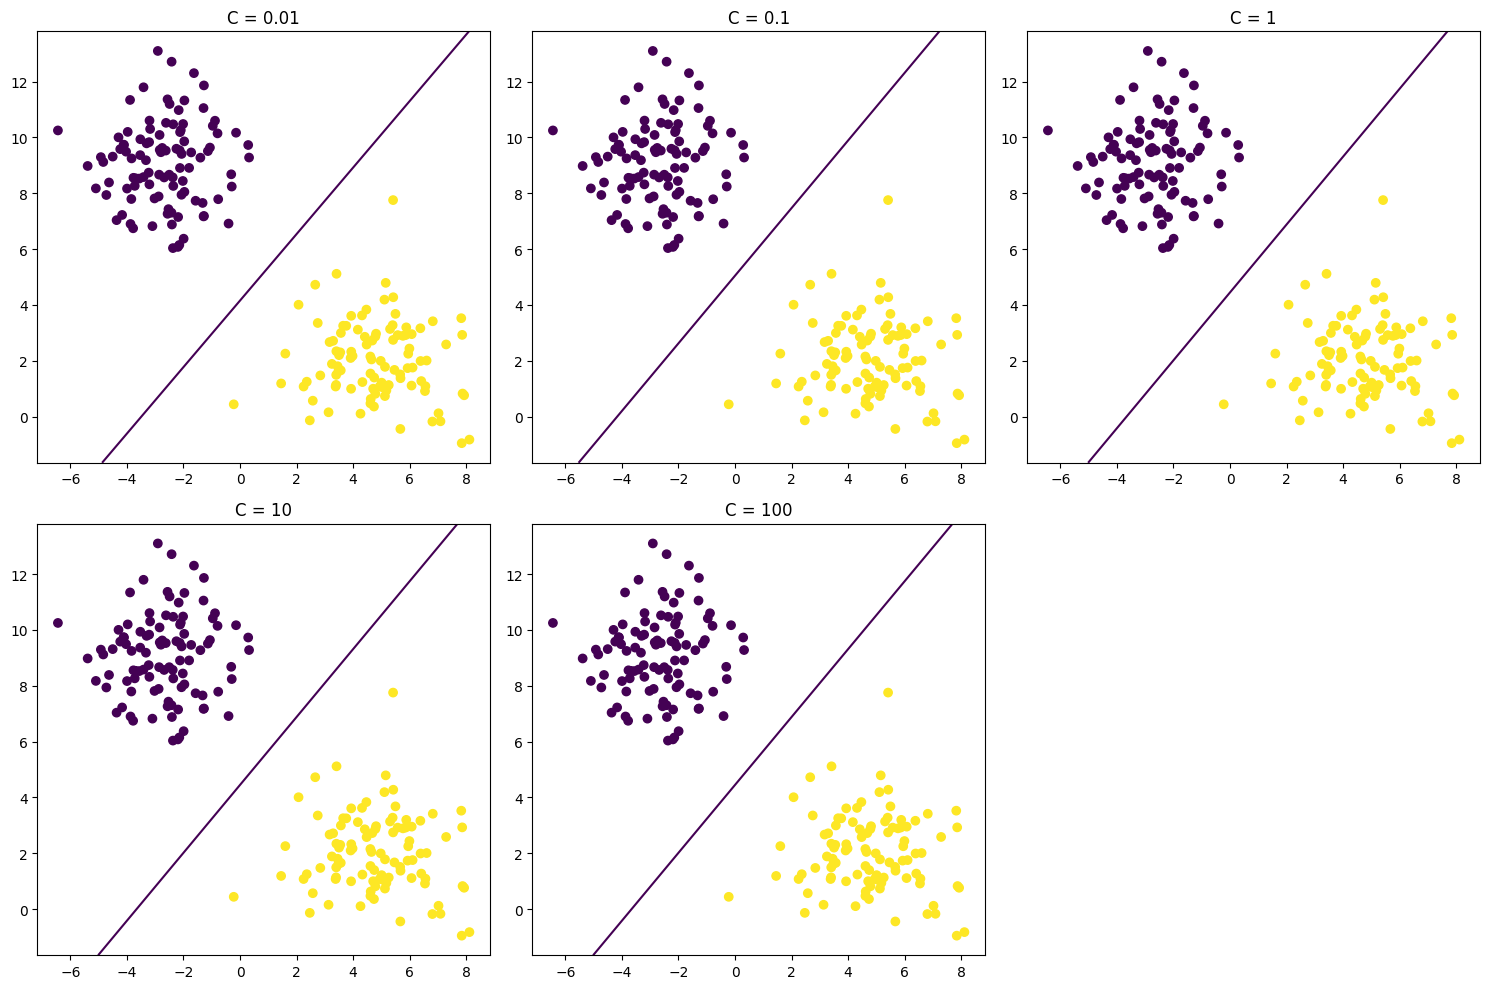

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

X_vis, y_vis = datasets.make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)

C_values = [0.01, 0.1, 1, 10, 100]

plt.figure(figsize=(15, 10))

for i, C in enumerate(C_values):
    model = SVC(kernel='linear', C=C)
    model.fit(X_vis, y_vis)

    plt.subplot(2, 3, i+1)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, levels=[0])

    plt.title(f"C = {C}")

plt.tight_layout()
plt.show()